In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   49                  22                      12   
1           2       0   56                  41                      25   
2           3       1   66                  41                      52   
3           4       1   69                  35                      85   
4           5       1   49                  44                      53   

   Cluster_No_Scaling  Cluster_With_Scaling  
0                   2                     1  
1                   2                     1  
2                   4                     4  
3                   4                     4  
4                   4                     1  


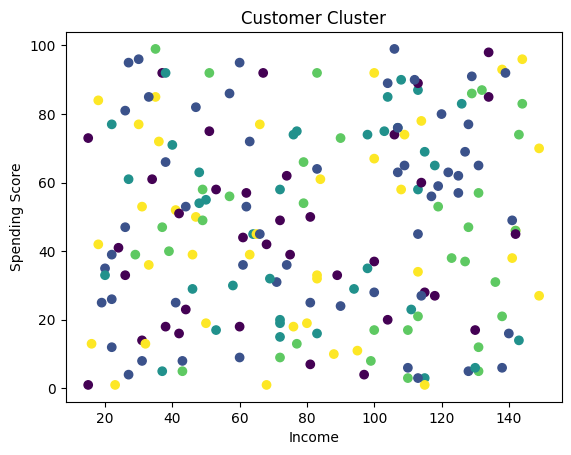

In [7]:
#Task1
np.random.seed(42)

data = {
    'CustomerID': range(1, 201),
    'Gender': np.random.choice(['Male', 'Female'], 200),
    'Age': np.random.randint(18, 70, 200),
    'Annual Income (k$)': np.random.randint(15, 150, 200),
    'Spending Score (1-100)': np.random.randint(1, 100, 200)
}

df = pd.DataFrame(data)

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

X = df.drop(columns=['CustomerID'])

kmeans1 = KMeans(n_clusters=5, random_state=42)
df['Cluster_No_Scaling'] = kmeans1.fit_predict(X)

scaler = StandardScaler()

X_scaled = X.copy()
cols_to_scale = ['Annual Income (k$)', 'Spending Score (1-100)', 'Gender']
X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

kmeans2 = KMeans(n_clusters=5, random_state=42)
df['Cluster_With_Scaling'] = kmeans2.fit_predict(X_scaled)

print(df.head())

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster_With_Scaling'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Cluster")
plt.show()

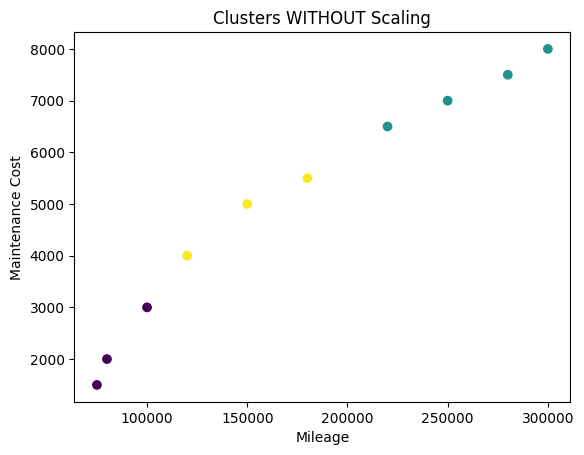

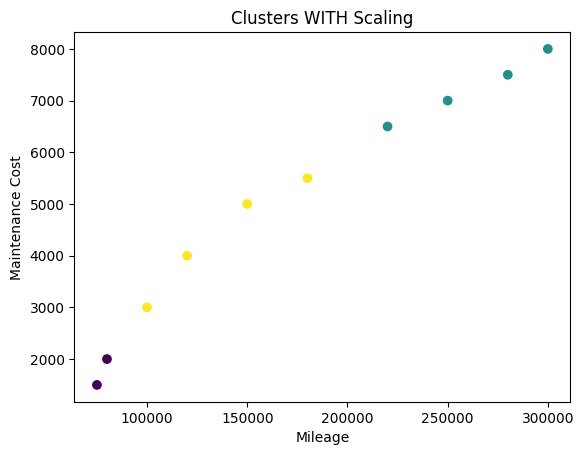

   vehicle_serial_no  mileage  fuel_efficiency  maintenance_cost  \
0                  5   150000               15              5000   
1                  3   120000               18              4000   
2                  8   250000               10              7000   
3                  2    80000               22              2000   
4                  4   100000               20              3000   
5                  7   220000               12              6500   
6                  6   180000               16              5500   
7                 10   300000                8              8000   
8                  1    75000               24              1500   
9                  9   280000                9              7500   

   vehicle_type  Cluster_No_Scaling  Cluster_With_Scaling  
0             1                   2                     2  
1             2                   2                     2  
2             3                   1                     1  
3          

In [8]:
#Task2
data = {
    'vehicle_serial_no': [5,3,8,2,4,7,6,10,1,9],
    'mileage': [150000,120000,250000,80000,100000,220000,180000,300000,75000,280000],
    'fuel_efficiency': [15,18,10,22,20,12,16,8,24,9],
    'maintenance_cost': [5000,4000,7000,2000,3000,6500,5500,8000,1500,7500],
    'vehicle_type': ['SUV','Sedan','Truck','Hatchback','Sedan','Truck','SUV','Truck','Hatchback','SUV']
}

df = pd.DataFrame(data)

le = LabelEncoder()
df['vehicle_type'] = le.fit_transform(df['vehicle_type'])

X = df.drop(columns=['vehicle_serial_no'])

kmeans1 = KMeans(n_clusters=3, random_state=42)
df['Cluster_No_Scaling'] = kmeans1.fit_predict(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans2 = KMeans(n_clusters=3, random_state=42)
df['Cluster_With_Scaling'] = kmeans2.fit_predict(X_scaled)

plt.figure()
plt.scatter(df['mileage'], df['maintenance_cost'], c=df['Cluster_No_Scaling'])
plt.xlabel("Mileage")
plt.ylabel("Maintenance Cost")
plt.title("Clusters WITHOUT Scaling")
plt.show()

plt.figure()
plt.scatter(df['mileage'], df['maintenance_cost'], c=df['Cluster_With_Scaling'])
plt.xlabel("Mileage")
plt.ylabel("Maintenance Cost")
plt.title("Clusters WITH Scaling")
plt.show()

print(df)

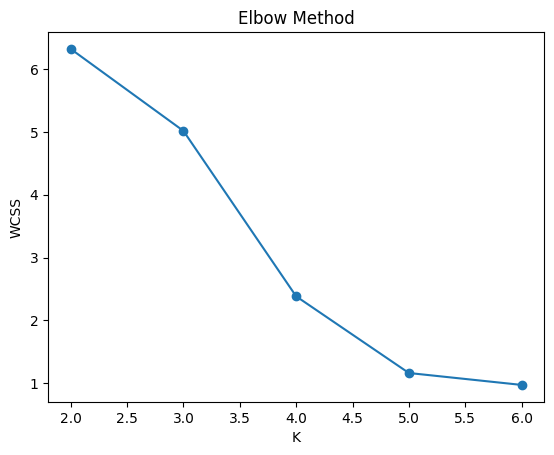

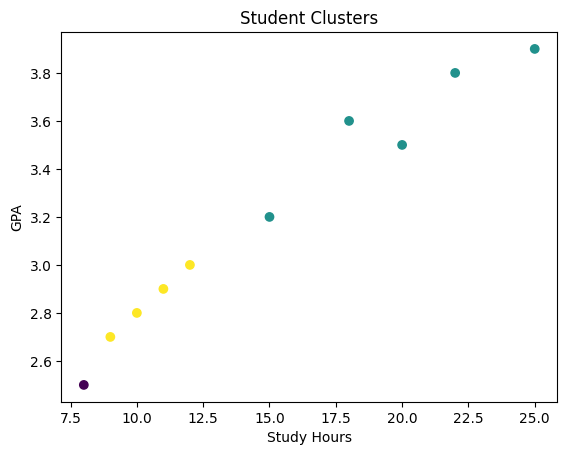

   student_id  GPA  study_hours  attendance_rate  Cluster
0           1  3.5           20               90        1
1           2  2.8           10               60        2
2           3  3.9           25               95        1
3           4  2.5            8               55        0
4           5  3.2           15               80        1
5           6  3.8           22               92        1
6           7  2.7            9               65        2
7           8  3.0           12               70        2
8           9  3.6           18               88        1
9          10  2.9           11               75        2


In [9]:
#Task3
data = {
    'student_id': [1,2,3,4,5,6,7,8,9,10],
    'GPA': [3.5, 2.8, 3.9, 2.5, 3.2, 3.8, 2.7, 3.0, 3.6, 2.9],
    'study_hours': [20, 10, 25, 8, 15, 22, 9, 12, 18, 11],
    'attendance_rate': [90, 60, 95, 55, 80, 92, 65, 70, 88, 75]
}

df = pd.DataFrame(data)

X = df[['GPA', 'study_hours', 'attendance_rate']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,7), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()


kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

plt.scatter(df['study_hours'], df['GPA'], c=df['Cluster'])
plt.xlabel("Study Hours")
plt.ylabel("GPA")
plt.title("Student Clusters")
plt.show()

print(df)